### 3.1.1 Problem Definition

While BERT models achieve high accuracy in fake news detection, they operate as "black boxes" — we know their predictions but not why. This investigation applies LIME (Local Interpretable Model-agnostic Explanations) and SHAP (SHapley Additive exPlanations) to understand:

1. **Which words most influence predictions** — Are emotional words, proper nouns, or sensational language driving the decision?
2. **How do the two models differ** — Does the Combined Specialist focus on different linguistic patterns than the Political Specialist?
3. **What semantic patterns emerge** — Can we identify common linguistic indicators of fake vs. real news?

This helps us validate model decisions and understand what language features distinguish fake from real news.

### 3.1.2 Setup and Imports

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from lime.lime_text import LimeTextExplainer
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
print(f"✅ Libraries loaded successfully!")

c:\Users\aweso\Documents\fakenews-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Using device: cuda
✅ Libraries loaded successfully!


### 3.1.3 Model Configuration

In [3]:
# Define model paths
MODEL_1_PATH = '../../models/bert_fake_news_trained_v2'
MODEL_1_NAME = 'Combined Specialist'

MODEL_2_PATH = '../../models/bert_politifact_retrained'
MODEL_2_NAME = 'Political Specialist'

MODEL_3_PATH = '../../models/bert_gossip'
MODEL_3_NAME = 'Gossip Specialist'

print(f"📊 Model Configuration:")
print(f"  Model 1: {MODEL_1_NAME}")
print(f"  Model 2: {MODEL_2_NAME}")
print(f"  Model 3: {MODEL_3_NAME}")

📊 Model Configuration:
  Model 1: Combined Specialist
  Model 2: Political Specialist
  Model 3: Gossip Specialist


### 3.1.4 Load Models

In [4]:
# Load models
print(f"🔄 Loading models...")
model_1 = AutoModelForSequenceClassification.from_pretrained(MODEL_1_PATH)
tokenizer_1 = AutoTokenizer.from_pretrained(MODEL_1_PATH)
model_1.to(device)
model_1.eval()

model_2 = AutoModelForSequenceClassification.from_pretrained(MODEL_2_PATH)
tokenizer_2 = AutoTokenizer.from_pretrained(MODEL_2_PATH)
model_2.to(device)
model_2.eval()

model_3 = AutoModelForSequenceClassification.from_pretrained(MODEL_3_PATH)
tokenizer_3 = AutoTokenizer.from_pretrained(MODEL_3_PATH)
model_3.to(device)
model_3.eval()

print(f"✅ Models loaded successfully!")

🔄 Loading models...
✅ Models loaded successfully!
✅ Models loaded successfully!


### 3.1.5 Prediction and LIME Setup Functions

In [6]:
def predict_text(text, model, tokenizer, device):
    """Get prediction and probabilities for a text sample"""
    text = str(text).strip()
    inputs = tokenizer(text, padding=True, truncation=True, max_length=128, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
        prediction = torch.argmax(logits, dim=-1).item()
        fake_prob = probs[0][0].item()
        real_prob = probs[0][1].item()
    
    return prediction, {'fake': fake_prob, 'real': real_prob}, max(fake_prob, real_prob)

def create_predictor(model, tokenizer, device):
    """Create prediction function for LIME"""
    def predict_fn(texts):
        predictions = []
        for text in texts:
            text = str(text) if isinstance(text, (list, tuple)) else text
            pred, probs, conf = predict_text(text, model, tokenizer, device)
            if probs:
                predictions.append([probs['fake'], probs['real']])
            else:
                predictions.append([0.5, 0.5])
        return np.array(predictions)
    return predict_fn

# Setup LIME explainers
print("⚙️  Setting up LIME explainers...")
explainer_1 = LimeTextExplainer(class_names=['Fake News', 'Real News'])
explainer_2 = LimeTextExplainer(class_names=['Fake News', 'Real News'])
explainer_3 = LimeTextExplainer(class_names=['Fake News', 'Real News'])

predictor_1 = create_predictor(model_1, tokenizer_1, device)
predictor_2 = create_predictor(model_2, tokenizer_2, device)
predictor_3 = create_predictor(model_3, tokenizer_3, device)

print("✅ Predictors and explainers ready")

⚙️  Setting up LIME explainers...
✅ Predictors and explainers ready


### 3.1.6 Visualization and Analysis Function

In [7]:
def analyze_sentence_with_lime(sentence, model_1, tokenizer_1, model_2, tokenizer_2, model_3, tokenizer_3,
                                explainer_1, explainer_2, explainer_3, predictor_1, predictor_2, predictor_3,
                                device, top_n=12):
    """
    Comprehensive LIME analysis of a sentence with all three models.
    Shows predictions, word importance, and highlighted sentence.
    """
    
    print(f"\n{'='*100}")
    print(f"SENTENCE ANALYSIS")
    print(f"{'='*100}")
    print(f"\n📄 Input: {sentence[:100]}..." if len(sentence) > 100 else f"\n📄 Input: {sentence}")
    
    # Get predictions for all 3 models
    pred_1, probs_1, conf_1 = predict_text(sentence, model_1, tokenizer_1, device)
    pred_1_label = 'REAL' if pred_1 == 1 else 'FAKE'
    
    pred_2, probs_2, conf_2 = predict_text(sentence, model_2, tokenizer_2, device)
    pred_2_label = 'REAL' if pred_2 == 1 else 'FAKE'
    
    pred_3, probs_3, conf_3 = predict_text(sentence, model_3, tokenizer_3, device)
    pred_3_label = 'REAL' if pred_3 == 1 else 'FAKE'
    
    print(f"\n🤖 PREDICTIONS:")
    print(f"  {MODEL_1_NAME}: {pred_1_label} ({conf_1:.2%} confidence)")
    print(f"  {MODEL_2_NAME}: {pred_2_label} ({conf_2:.2%} confidence)")
    print(f"  {MODEL_3_NAME}: {pred_3_label} ({conf_3:.2%} confidence)")
    
    # Run LIME explanations for all 3 models
    print(f"\n⏳ Computing LIME explanations...")
    
    exp_1 = explainer_1.explain_instance(sentence, predictor_1, num_features=top_n, num_samples=1000)
    lime_weights_1 = exp_1.as_list()
    
    exp_2 = explainer_2.explain_instance(sentence, predictor_2, num_features=top_n, num_samples=1000)
    lime_weights_2 = exp_2.as_list()
    
    exp_3 = explainer_3.explain_instance(sentence, predictor_3, num_features=top_n, num_samples=1000)
    lime_weights_3 = exp_3.as_list()
    
    print(f"✅ LIME explanations complete!")
    
    # Create DataFrames for all 3 models
    df_1 = pd.DataFrame(lime_weights_1, columns=['word', 'contribution'])
    df_1['direction'] = df_1['contribution'].apply(lambda x: 'REAL' if x > 0 else 'FAKE')
    df_1['abs_contribution'] = abs(df_1['contribution'])
    df_1 = df_1.sort_values('abs_contribution', ascending=False)
    
    df_2 = pd.DataFrame(lime_weights_2, columns=['word', 'contribution'])
    df_2['direction'] = df_2['contribution'].apply(lambda x: 'REAL' if x > 0 else 'FAKE')
    df_2['abs_contribution'] = abs(df_2['contribution'])
    df_2 = df_2.sort_values('abs_contribution', ascending=False)
    
    df_3 = pd.DataFrame(lime_weights_3, columns=['word', 'contribution'])
    df_3['direction'] = df_3['contribution'].apply(lambda x: 'REAL' if x > 0 else 'FAKE')
    df_3['abs_contribution'] = abs(df_3['contribution'])
    df_3 = df_3.sort_values('abs_contribution', ascending=False)
    
    # === Visualization 1: Square figure (LaTeX-compatible) ===
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    fig.suptitle('LIME Analysis: Word Importance Across Three Models', fontsize=14, fontweight='bold', y=0.995)
    
    # Model 1 (top-left)
    colors_1 = df_1.head(top_n)['direction'].map({'REAL': '#2ecc71', 'FAKE': '#e74c3c'})
    axes[0, 0].barh(df_1.head(top_n)['word'], df_1.head(top_n)['contribution'], color=colors_1, edgecolor='black', linewidth=0.5)
    axes[0, 0].set_xlabel('Contribution', fontsize=10, fontweight='bold')
    axes[0, 0].set_title(f"{MODEL_1_NAME}\n({pred_1_label} - {conf_1:.1%})", fontsize=11, fontweight='bold')
    axes[0, 0].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    # Model 2 (top-right)
    colors_2 = df_2.head(top_n)['direction'].map({'REAL': '#2ecc71', 'FAKE': '#e74c3c'})
    axes[0, 1].barh(df_2.head(top_n)['word'], df_2.head(top_n)['contribution'], color=colors_2, edgecolor='black', linewidth=0.5)
    axes[0, 1].set_xlabel('Contribution', fontsize=10, fontweight='bold')
    axes[0, 1].set_title(f"{MODEL_2_NAME}\n({pred_2_label} - {conf_2:.1%})", fontsize=11, fontweight='bold')
    axes[0, 1].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[0, 1].invert_yaxis()
    axes[0, 1].grid(axis='x', alpha=0.3)
    
    # Model 3 (bottom-left)
    colors_3 = df_3.head(top_n)['direction'].map({'REAL': '#2ecc71', 'FAKE': '#e74c3c'})
    axes[1, 0].barh(df_3.head(top_n)['word'], df_3.head(top_n)['contribution'], color=colors_3, edgecolor='black', linewidth=0.5)
    axes[1, 0].set_xlabel('Contribution', fontsize=10, fontweight='bold')
    axes[1, 0].set_title(f"{MODEL_3_NAME}\n({pred_3_label} - {conf_3:.1%})", fontsize=11, fontweight='bold')
    axes[1, 0].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[1, 0].invert_yaxis()
    axes[1, 0].grid(axis='x', alpha=0.3)
    
    # Summary statistics (bottom-right)
    axes[1, 1].axis('off')
    summary_text = f"""
PREDICTION SUMMARY

{MODEL_1_NAME}:
  Prediction: {pred_1_label}
  Confidence: {conf_1:.1%}

{MODEL_2_NAME}:
  Prediction: {pred_2_label}
  Confidence: {conf_2:.1%}

{MODEL_3_NAME}:
  Prediction: {pred_3_label}
  Confidence: {conf_3:.1%}

Input Sentence:
{sentence[:80]}{'...' if len(sentence) > 80 else ''}
    """
    axes[1, 1].text(0.1, 0.5, summary_text, fontsize=10, verticalalignment='center', 
                    family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig('lime_analysis_square.png', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    print("✅ Figure saved as: lime_analysis_square.png")
    plt.show()
    
    # === Visualization 2: Highlighted sentence for all 3 models ===
    print(f"\n📍 SENTENCE HIGHLIGHTING:")
    print(f"\n{MODEL_1_NAME}:")
    highlight_sentence(sentence, df_1)
    
    print(f"\n{MODEL_2_NAME}:")
    highlight_sentence(sentence, df_2)
    
    print(f"\n{MODEL_3_NAME}:")
    highlight_sentence(sentence, df_3)
    
    # === Summary table for all 3 models ===
    print(f"\n\n📊 TOP INFLUENTIAL WORDS:")
    
    summary_data = []
    for i in range(top_n//3):
        summary_data.append({
            f'{MODEL_1_NAME}': df_1.iloc[i]['word'] if i < len(df_1) else '',
            'Weight': f"{df_1.iloc[i]['contribution']:.3f}" if i < len(df_1) else '',
            f'{MODEL_2_NAME}': df_2.iloc[i]['word'] if i < len(df_2) else '',
            'Weight ': f"{df_2.iloc[i]['contribution']:.3f}" if i < len(df_2) else '',
            f'{MODEL_3_NAME}': df_3.iloc[i]['word'] if i < len(df_3) else '',
            'Weight  ': f"{df_3.iloc[i]['contribution']:.3f}" if i < len(df_3) else ''
        })
    
    summary_df = pd.DataFrame(summary_data)
    display(summary_df)
    
    # === Semantic Analysis for all 3 models ===
    print(f"\n\n🔍 SEMANTIC ANALYSIS:")
    analyze_semantic_patterns(df_1, df_2, df_3, MODEL_1_NAME, MODEL_2_NAME, MODEL_3_NAME)
    
    return {
        'sentence': sentence,
        'model_1_pred': pred_1_label,
        'model_1_conf': conf_1,
        'model_2_pred': pred_2_label,
        'model_2_conf': conf_2,
        'model_3_pred': pred_3_label,
        'model_3_conf': conf_3,
        'df_1': df_1,
        'df_2': df_2,
        'df_3': df_3
    }

def highlight_sentence(sentence, df_weights):
    """Create color-highlighted HTML version of sentence with smart word matching"""
    # Build contribution dictionary - LIME may return partial phrases
    # Keep both cleaned and original versions for matching
    lime_words = df_weights['word'].tolist()
    lime_words_lower = [w.lower().strip('.,!?;:') for w in lime_words]
    contrib_dict = dict(zip(lime_words_lower, df_weights['contribution'].tolist()))
    
    # Split sentence and process
    sentence_words = sentence.split()
    highlighted = []
    used_indices = set()
    
    i = 0
    while i < len(sentence_words):
        word = sentence_words[i]
        clean_word = word.lower().strip('.,!?;:')
        
        # Try multi-word phrases first (up to 4 words)
        found = False
        for phrase_len in [4, 3, 2]:
            if i + phrase_len <= len(sentence_words):
                # Build potential phrase
                phrase = ' '.join([w.lower().strip('.,!?;:') for w in sentence_words[i:i+phrase_len]])
                if phrase in contrib_dict:
                    # Found a match - highlight all words in phrase
                    score = contrib_dict[phrase]
                    
                    for j in range(i, i + phrase_len):
                        if score > 0:
                            color = f"rgba(0, 200, 0, 0.4)"  # Green for REAL
                        else:
                            color = f"rgba(255, 0, 0, 0.4)"  # Red for FAKE
                        
                        w = sentence_words[j]
                        highlighted.append(f"<span style='background-color:{color}; padding: 2px 4px; border-radius: 3px;'>{w}</span>")
                        used_indices.add(j)
                    i += phrase_len
                    found = True
                    break
        
        # If no multi-word phrase found, try single word
        if not found:
            if clean_word in contrib_dict:
                score = contrib_dict[clean_word]
                
                if score > 0:
                    color = f"rgba(0, 200, 0, 0.4)"  # Green for REAL
                else:
                    color = f"rgba(255, 0, 0, 0.4)"  # Red for FAKE
                highlighted.append(f"<span style='background-color:{color}; padding: 2px 4px; border-radius: 3px;'>{word}</span>")
                used_indices.add(i)
            else:
                # No match found, add unhighlighted
                highlighted.append(word)
            i += 1
    
    html_sentence = " ".join(highlighted)
    display(HTML(f"<p style='font-size:1.1em; line-height:1.8;'>{html_sentence}</p>"))

def analyze_semantic_patterns(df_1, df_2, df_3, model_1_name, model_2_name, model_3_name):
    """Analyze semantic categories in the top words"""
    # Define semantic categories
    emotional_words = {'demonic', 'infernal', 'wretched', 'malevolent', 'terrible', 'screeching', 'blasphemy', 'torment', 'vile', 'debauchery', 'shocked', 'anger', 'outrage'}
    sensational_words = {'unprecedented', 'shocking', 'milestone', 'historic', 'radical', 'innovative', 'extraordinary', 'remarkable', 'stunning', 'incredible'}
    vague_words = {'many', 'countless', 'some', 'several', 'strange', 'defy', 'unexplained', 'mysterious', 'unknown', 'alleged'}
    
    def count_category(words, category):
        return sum(1 for w in words if any(c in w.lower() for c in category))
    
    words_1 = df_1.head(15)['word'].str.lower().tolist()
    words_2 = df_2.head(15)['word'].str.lower().tolist()
    words_3 = df_3.head(15)['word'].str.lower().tolist()
    
    print(f"\n{model_1_name}:")
    print(f"  Emotional Language: {count_category(words_1, emotional_words)} words")
    print(f"  Sensational Markers: {count_category(words_1, sensational_words)} words")
    print(f"  Vague Language: {count_category(words_1, vague_words)} words")
    
    print(f"\n{model_2_name}:")
    print(f"  Emotional Language: {count_category(words_2, emotional_words)} words")
    print(f"  Sensational Markers: {count_category(words_2, sensational_words)} words")
    print(f"  Vague Language: {count_category(words_2, vague_words)} words")
    
    print(f"\n{model_3_name}:")
    print(f"  Emotional Language: {count_category(words_3, emotional_words)} words")
    print(f"  Sensational Markers: {count_category(words_3, sensational_words)} words")
    print(f"  Vague Language: {count_category(words_3, vague_words)} words")

### 3.1.7 Investigation Examples


SENTENCE ANALYSIS

📄 Input: Trump and Putin are meeting for a summit to discuss trade agreements and nuclear proliferation conce...

🤖 PREDICTIONS:
  Combined Specialist: REAL (99.97% confidence)
  Political Specialist: REAL (88.93% confidence)
  Gossip Specialist: FAKE (96.90% confidence)

⏳ Computing LIME explanations...
✅ LIME explanations complete!
✅ Figure saved as: lime_analysis_square.png



SENTENCE ANALYSIS

📄 Input: Trump and Putin are meeting for a summit to discuss trade agreements and nuclear proliferation conce...

🤖 PREDICTIONS:
  Combined Specialist: REAL (99.97% confidence)
  Political Specialist: REAL (88.93% confidence)
  Gossip Specialist: FAKE (96.90% confidence)

⏳ Computing LIME explanations...
✅ LIME explanations complete!
✅ Figure saved as: lime_analysis_square.png


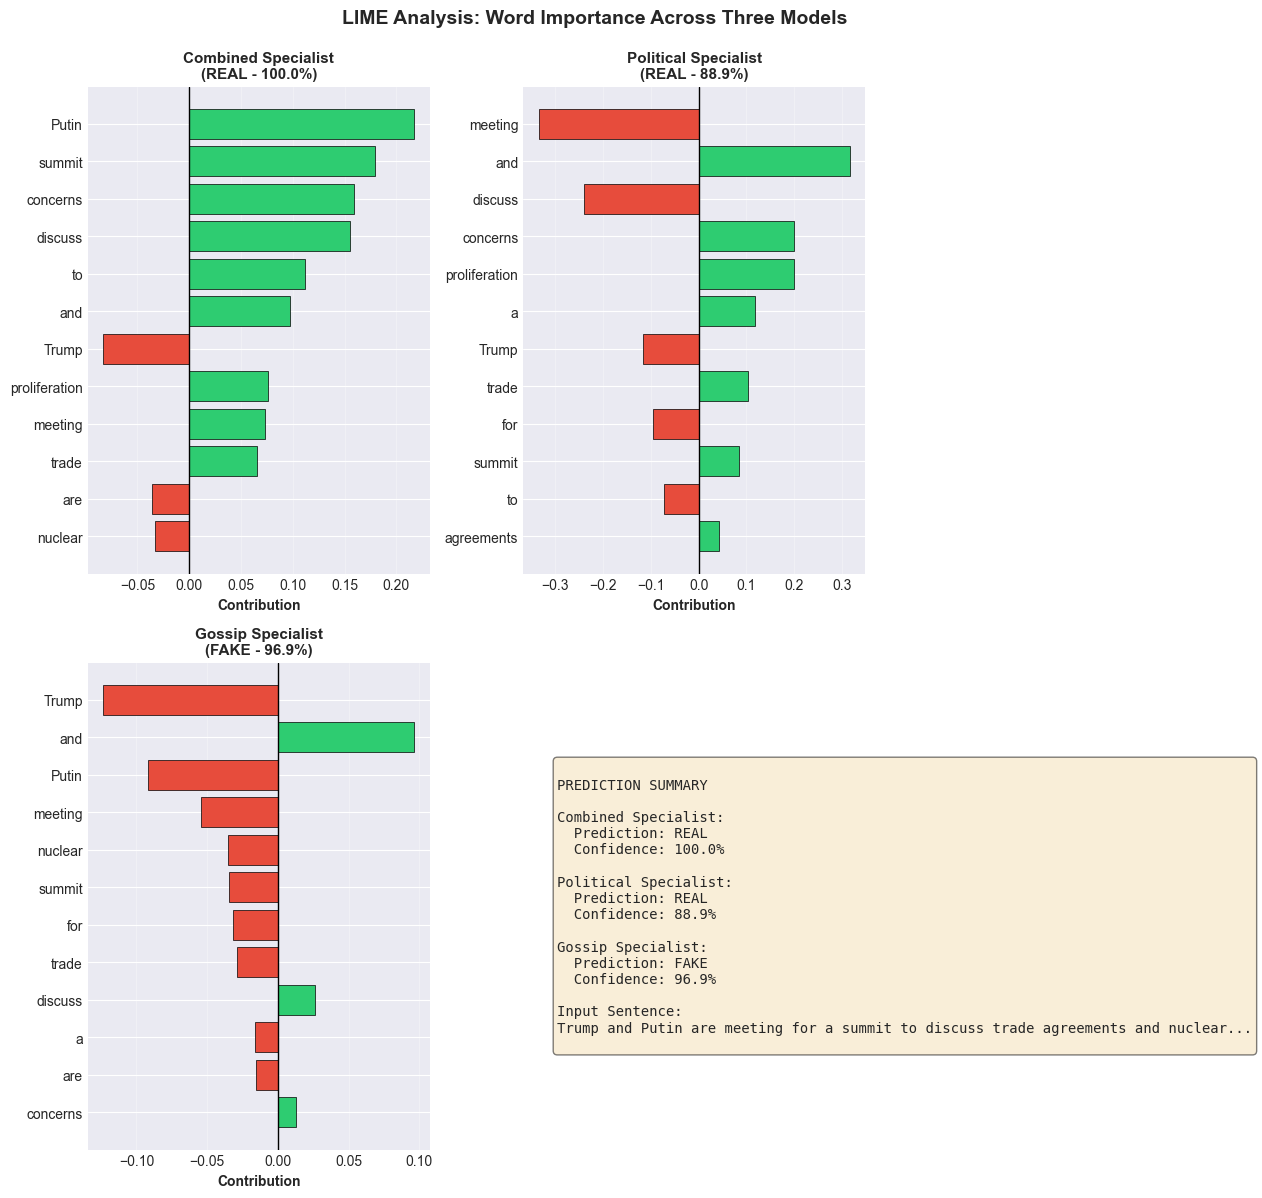


📍 SENTENCE HIGHLIGHTING:

Combined Specialist:



SENTENCE ANALYSIS

📄 Input: Trump and Putin are meeting for a summit to discuss trade agreements and nuclear proliferation conce...

🤖 PREDICTIONS:
  Combined Specialist: REAL (99.97% confidence)
  Political Specialist: REAL (88.93% confidence)
  Gossip Specialist: FAKE (96.90% confidence)

⏳ Computing LIME explanations...
✅ LIME explanations complete!
✅ Figure saved as: lime_analysis_square.png


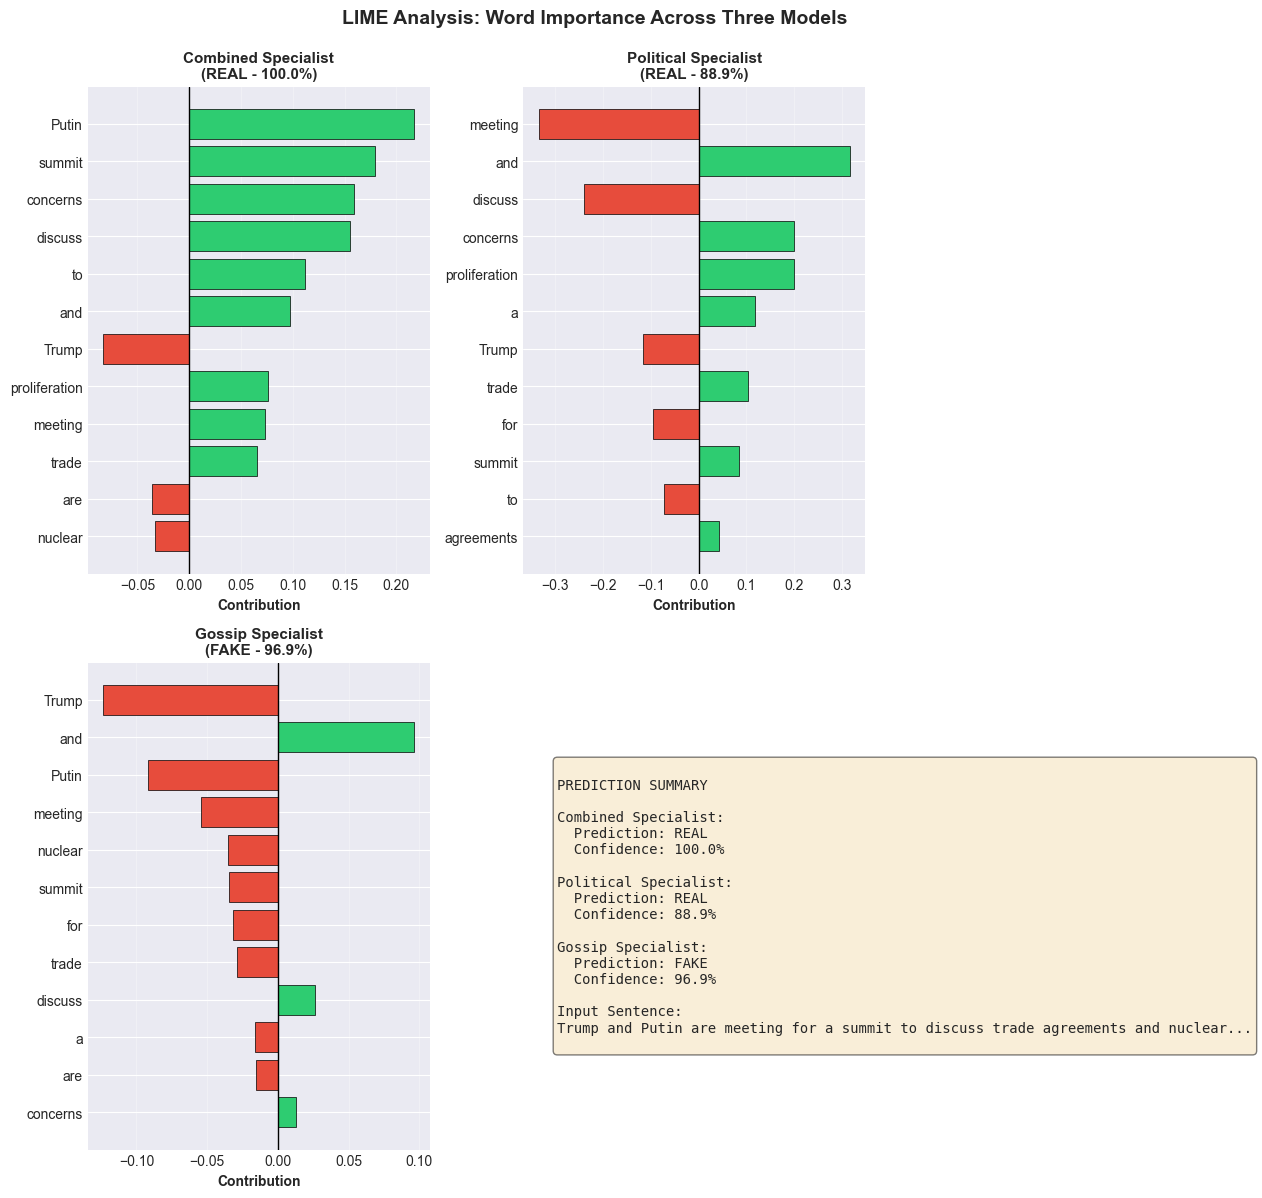


📍 SENTENCE HIGHLIGHTING:

Combined Specialist:



Political Specialist:



Gossip Specialist:



SENTENCE ANALYSIS

📄 Input: Trump and Putin are meeting for a summit to discuss trade agreements and nuclear proliferation conce...

🤖 PREDICTIONS:
  Combined Specialist: REAL (99.97% confidence)
  Political Specialist: REAL (88.93% confidence)
  Gossip Specialist: FAKE (96.90% confidence)

⏳ Computing LIME explanations...
✅ LIME explanations complete!
✅ Figure saved as: lime_analysis_square.png


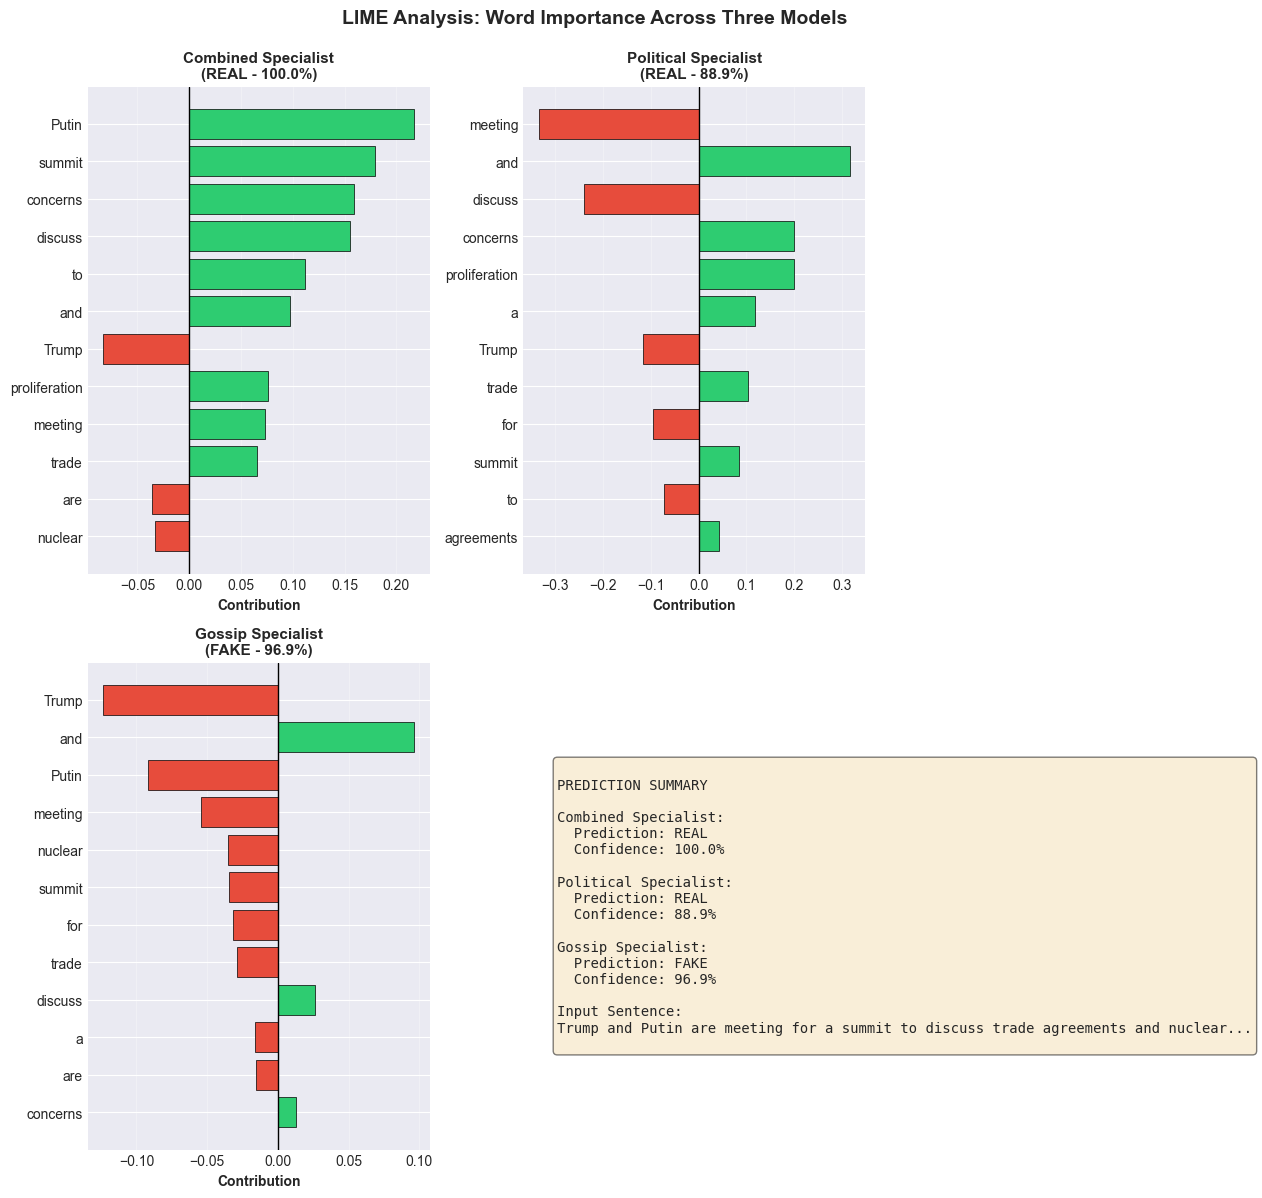


📍 SENTENCE HIGHLIGHTING:

Combined Specialist:



Political Specialist:



Gossip Specialist:




📊 TOP INFLUENTIAL WORDS:


,Combined Specialist,Weight,Political Specialist,Weight,Gossip Specialist,Weight
0,Putin,0.217,meeting,-0.334,Trump,-0.123
1,summit,0.180,and,0.316,and,0.096
2,concerns,0.159,discuss,-0.239,Putin,-0.092
3,discuss,0.155,concerns,0.199,meeting,-0.054



SENTENCE ANALYSIS

📄 Input: Trump and Putin are meeting for a summit to discuss trade agreements and nuclear proliferation conce...

🤖 PREDICTIONS:
  Combined Specialist: REAL (99.97% confidence)
  Political Specialist: REAL (88.93% confidence)
  Gossip Specialist: FAKE (96.90% confidence)

⏳ Computing LIME explanations...
✅ LIME explanations complete!
✅ Figure saved as: lime_analysis_square.png


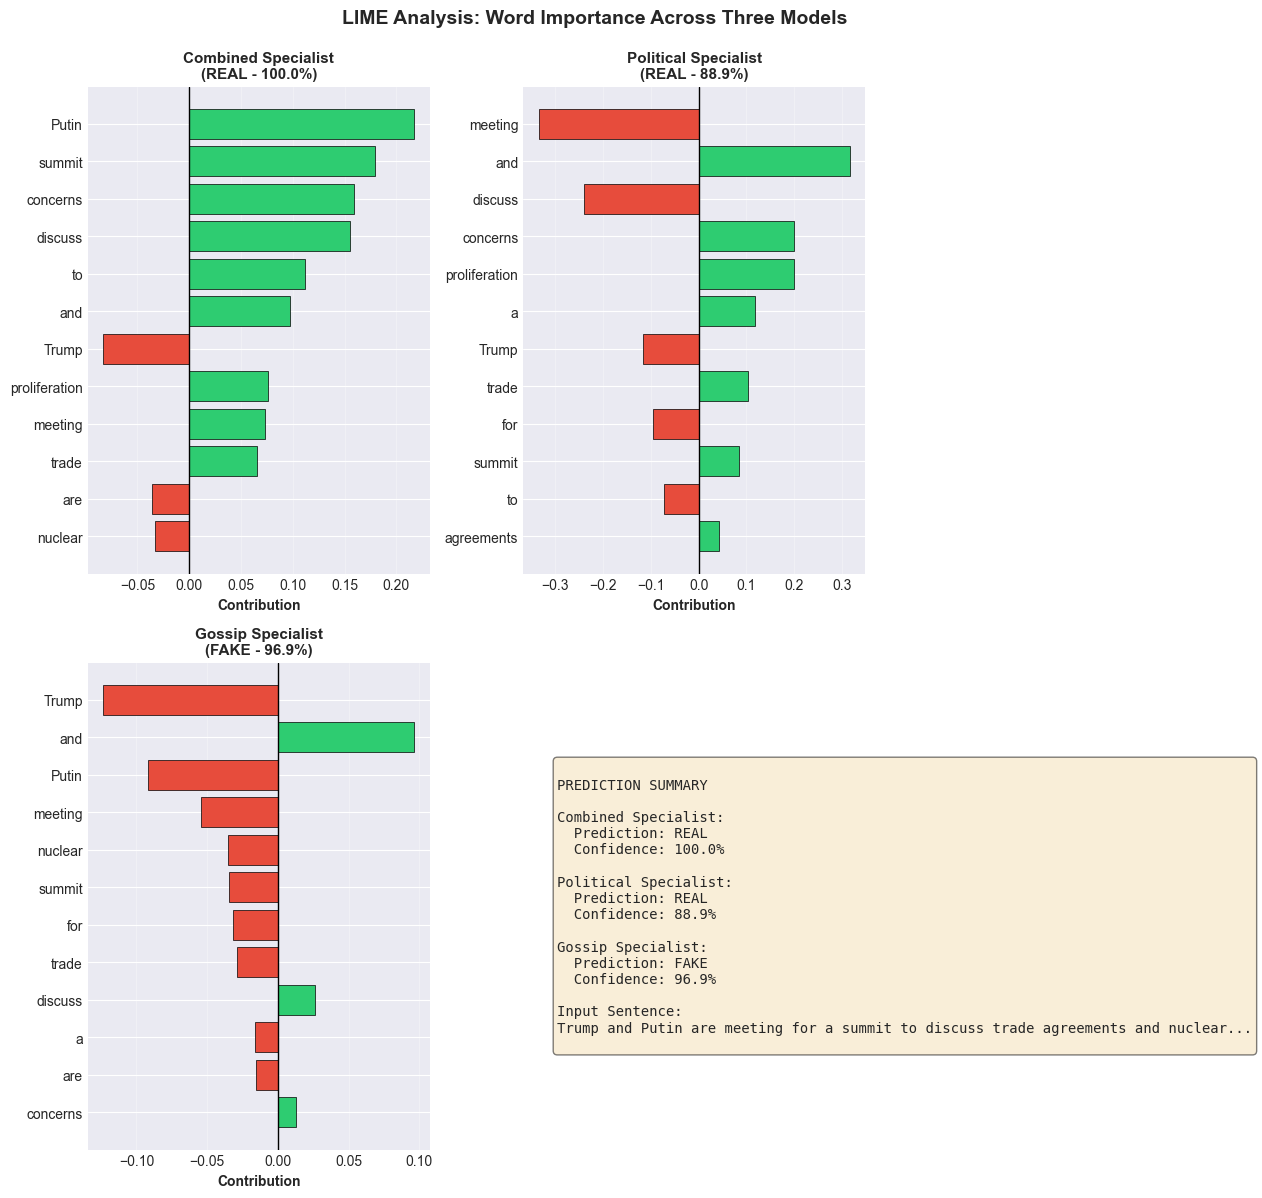


📍 SENTENCE HIGHLIGHTING:

Combined Specialist:



Political Specialist:



Gossip Specialist:




📊 TOP INFLUENTIAL WORDS:


,Combined Specialist,Weight,Political Specialist,Weight,Gossip Specialist,Weight
0,Putin,0.217,meeting,-0.334,Trump,-0.123
1,summit,0.180,and,0.316,and,0.096
2,concerns,0.159,discuss,-0.239,Putin,-0.092
3,discuss,0.155,concerns,0.199,meeting,-0.054




🔍 SEMANTIC ANALYSIS:

Combined Specialist:
  Emotional Language: 0 words
  Sensational Markers: 0 words
  Vague Language: 0 words

Political Specialist:
  Emotional Language: 0 words
  Sensational Markers: 0 words
  Vague Language: 0 words

Gossip Specialist:
  Emotional Language: 0 words
  Sensational Markers: 0 words
  Vague Language: 0 words

SENTENCE ANALYSIS

📄 Input: SHOCKING: Trump's INCREDIBLE secret meeting with Putin REVEALED - You won't believe what they discus...

🤖 PREDICTIONS:
  Combined Specialist: FAKE (99.99% confidence)
  Political Specialist: FAKE (100.00% confidence)
  Gossip Specialist: FAKE (83.42% confidence)

⏳ Computing LIME explanations...

🤖 PREDICTIONS:
  Combined Specialist: FAKE (99.99% confidence)
  Political Specialist: FAKE (100.00% confidence)
  Gossip Specialist: FAKE (83.42% confidence)

⏳ Computing LIME explanations...
✅ LIME explanations complete!
✅ LIME explanations complete!
✅ Figure saved as: lime_analysis_square.png
✅ Figure saved as: lime_an


SENTENCE ANALYSIS

📄 Input: Trump and Putin are meeting for a summit to discuss trade agreements and nuclear proliferation conce...

🤖 PREDICTIONS:
  Combined Specialist: REAL (99.97% confidence)
  Political Specialist: REAL (88.93% confidence)
  Gossip Specialist: FAKE (96.90% confidence)

⏳ Computing LIME explanations...
✅ LIME explanations complete!
✅ Figure saved as: lime_analysis_square.png


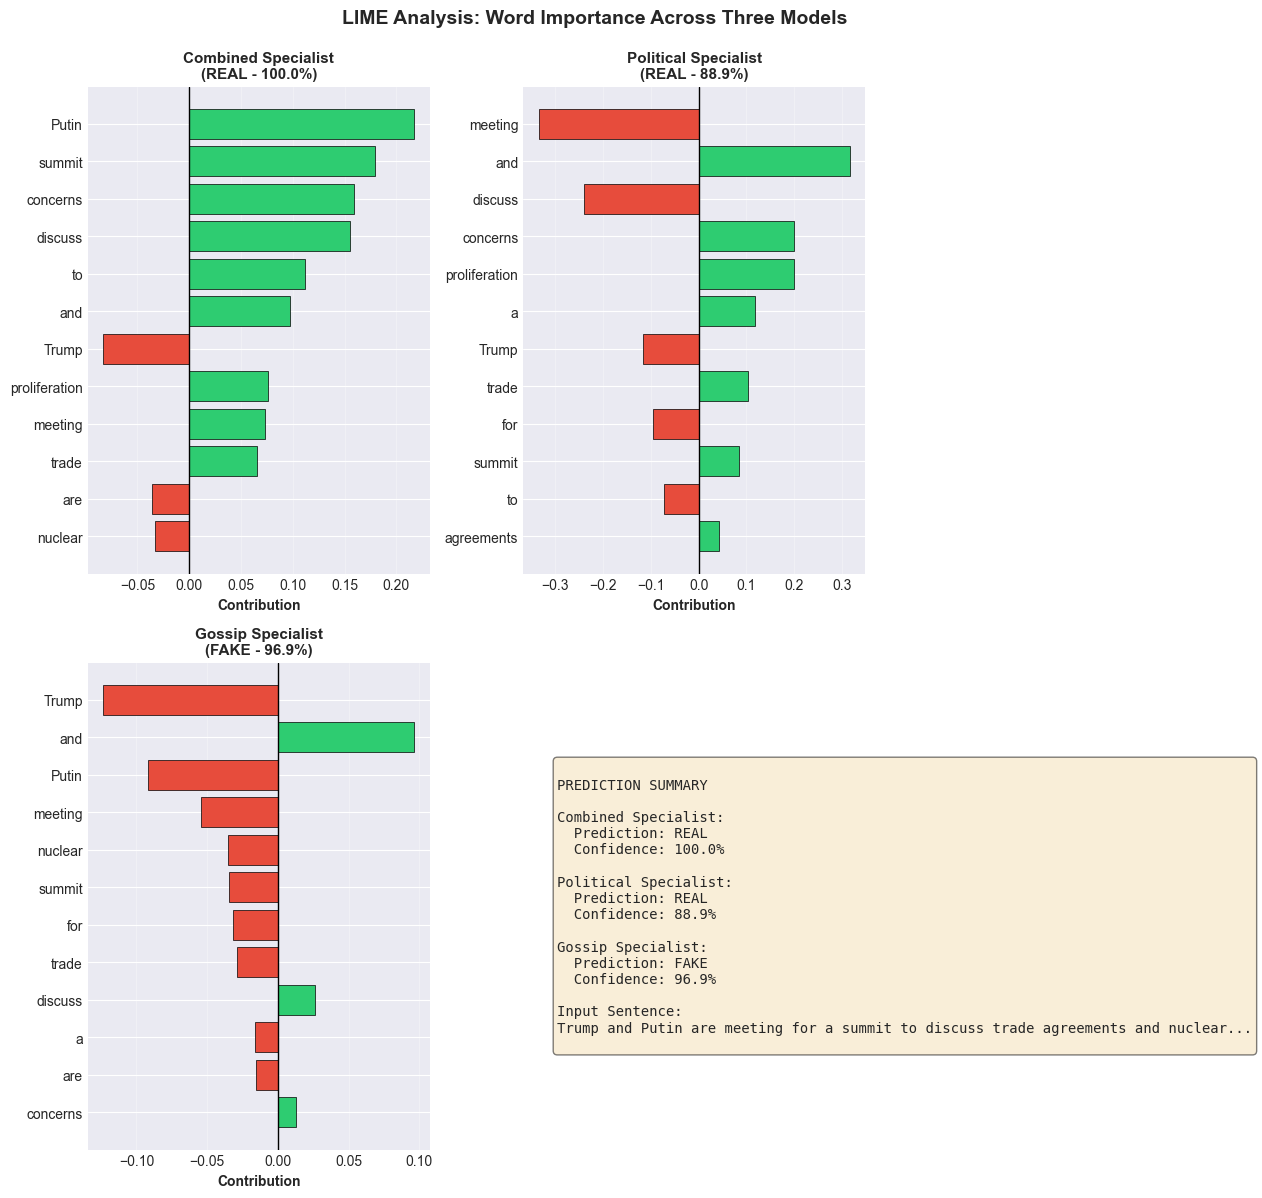


📍 SENTENCE HIGHLIGHTING:

Combined Specialist:



Political Specialist:



Gossip Specialist:




📊 TOP INFLUENTIAL WORDS:


,Combined Specialist,Weight,Political Specialist,Weight,Gossip Specialist,Weight
0,Putin,0.217,meeting,-0.334,Trump,-0.123
1,summit,0.180,and,0.316,and,0.096
2,concerns,0.159,discuss,-0.239,Putin,-0.092
3,discuss,0.155,concerns,0.199,meeting,-0.054




🔍 SEMANTIC ANALYSIS:

Combined Specialist:
  Emotional Language: 0 words
  Sensational Markers: 0 words
  Vague Language: 0 words

Political Specialist:
  Emotional Language: 0 words
  Sensational Markers: 0 words
  Vague Language: 0 words

Gossip Specialist:
  Emotional Language: 0 words
  Sensational Markers: 0 words
  Vague Language: 0 words

SENTENCE ANALYSIS

📄 Input: SHOCKING: Trump's INCREDIBLE secret meeting with Putin REVEALED - You won't believe what they discus...

🤖 PREDICTIONS:
  Combined Specialist: FAKE (99.99% confidence)
  Political Specialist: FAKE (100.00% confidence)
  Gossip Specialist: FAKE (83.42% confidence)

⏳ Computing LIME explanations...

🤖 PREDICTIONS:
  Combined Specialist: FAKE (99.99% confidence)
  Political Specialist: FAKE (100.00% confidence)
  Gossip Specialist: FAKE (83.42% confidence)

⏳ Computing LIME explanations...
✅ LIME explanations complete!
✅ LIME explanations complete!
✅ Figure saved as: lime_analysis_square.png
✅ Figure saved as: lime_an

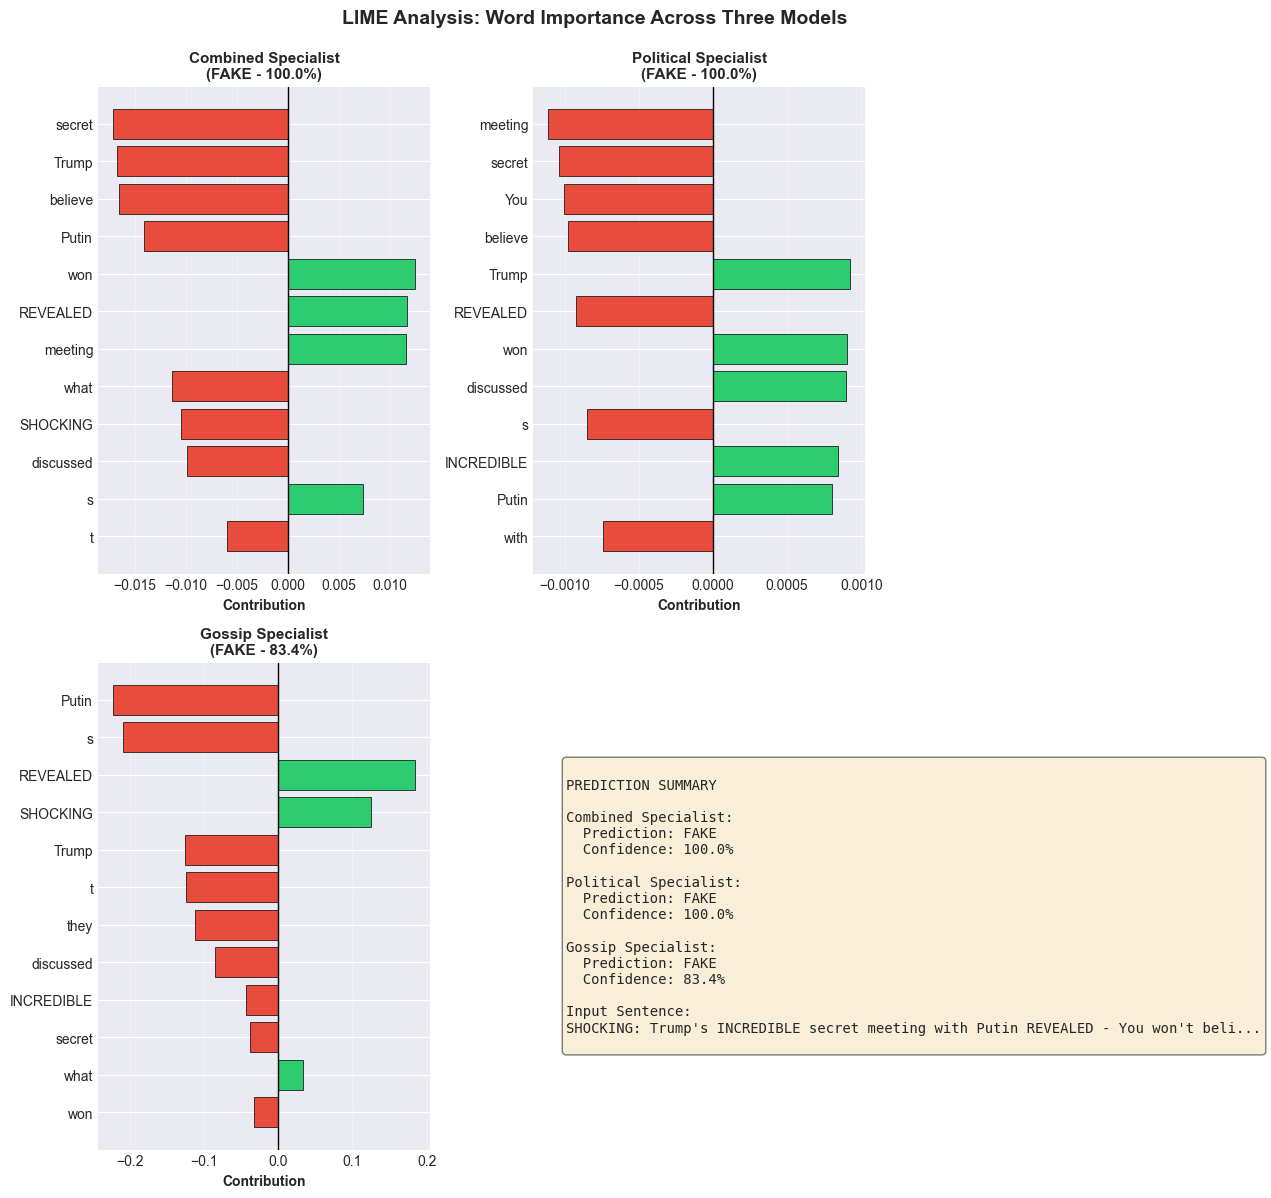


📍 SENTENCE HIGHLIGHTING:

Combined Specialist:



Political Specialist:



Gossip Specialist:




📊 TOP INFLUENTIAL WORDS:


,Combined Specialist,Weight,Political Specialist,Weight,Gossip Specialist,Weight
0,secret,-0.017,meeting,-0.001,Putin,-0.222
1,Trump,-0.017,secret,-0.001,s,-0.209
2,believe,-0.017,You,-0.001,REVEALED,0.184
3,Putin,-0.014,believe,-0.001,SHOCKING,0.126



SENTENCE ANALYSIS

📄 Input: Trump and Putin are meeting for a summit to discuss trade agreements and nuclear proliferation conce...

🤖 PREDICTIONS:
  Combined Specialist: REAL (99.97% confidence)
  Political Specialist: REAL (88.93% confidence)
  Gossip Specialist: FAKE (96.90% confidence)

⏳ Computing LIME explanations...
✅ LIME explanations complete!
✅ Figure saved as: lime_analysis_square.png


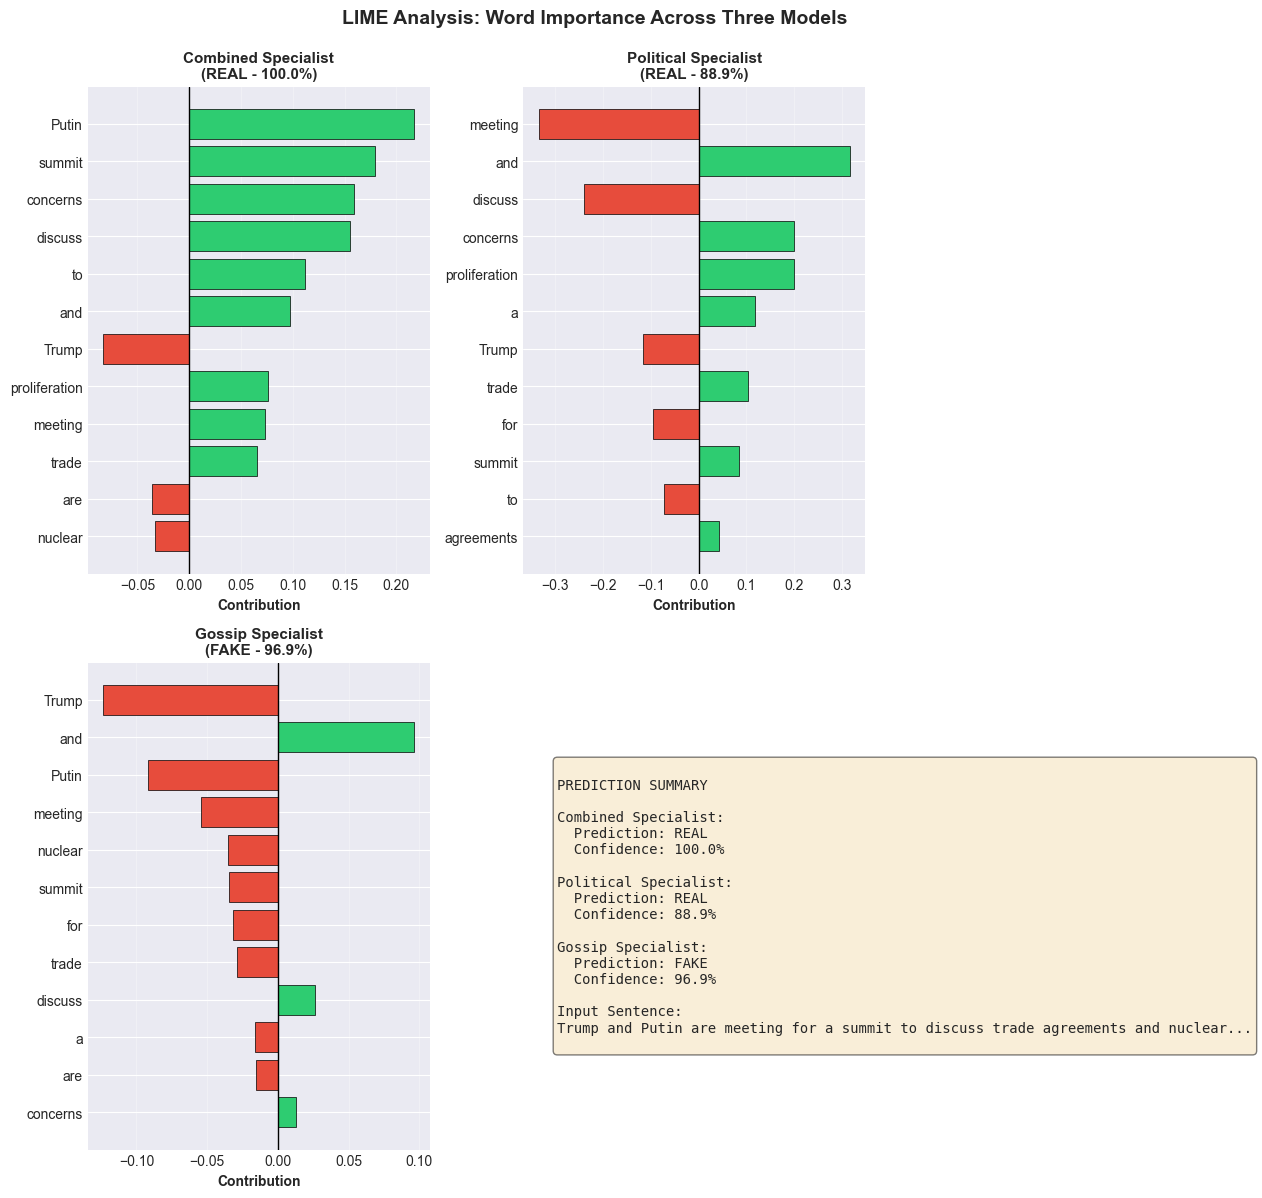


📍 SENTENCE HIGHLIGHTING:

Combined Specialist:



Political Specialist:



Gossip Specialist:




📊 TOP INFLUENTIAL WORDS:


,Combined Specialist,Weight,Political Specialist,Weight,Gossip Specialist,Weight
0,Putin,0.217,meeting,-0.334,Trump,-0.123
1,summit,0.180,and,0.316,and,0.096
2,concerns,0.159,discuss,-0.239,Putin,-0.092
3,discuss,0.155,concerns,0.199,meeting,-0.054




🔍 SEMANTIC ANALYSIS:

Combined Specialist:
  Emotional Language: 0 words
  Sensational Markers: 0 words
  Vague Language: 0 words

Political Specialist:
  Emotional Language: 0 words
  Sensational Markers: 0 words
  Vague Language: 0 words

Gossip Specialist:
  Emotional Language: 0 words
  Sensational Markers: 0 words
  Vague Language: 0 words

SENTENCE ANALYSIS

📄 Input: SHOCKING: Trump's INCREDIBLE secret meeting with Putin REVEALED - You won't believe what they discus...

🤖 PREDICTIONS:
  Combined Specialist: FAKE (99.99% confidence)
  Political Specialist: FAKE (100.00% confidence)
  Gossip Specialist: FAKE (83.42% confidence)

⏳ Computing LIME explanations...

🤖 PREDICTIONS:
  Combined Specialist: FAKE (99.99% confidence)
  Political Specialist: FAKE (100.00% confidence)
  Gossip Specialist: FAKE (83.42% confidence)

⏳ Computing LIME explanations...
✅ LIME explanations complete!
✅ LIME explanations complete!
✅ Figure saved as: lime_analysis_square.png
✅ Figure saved as: lime_an

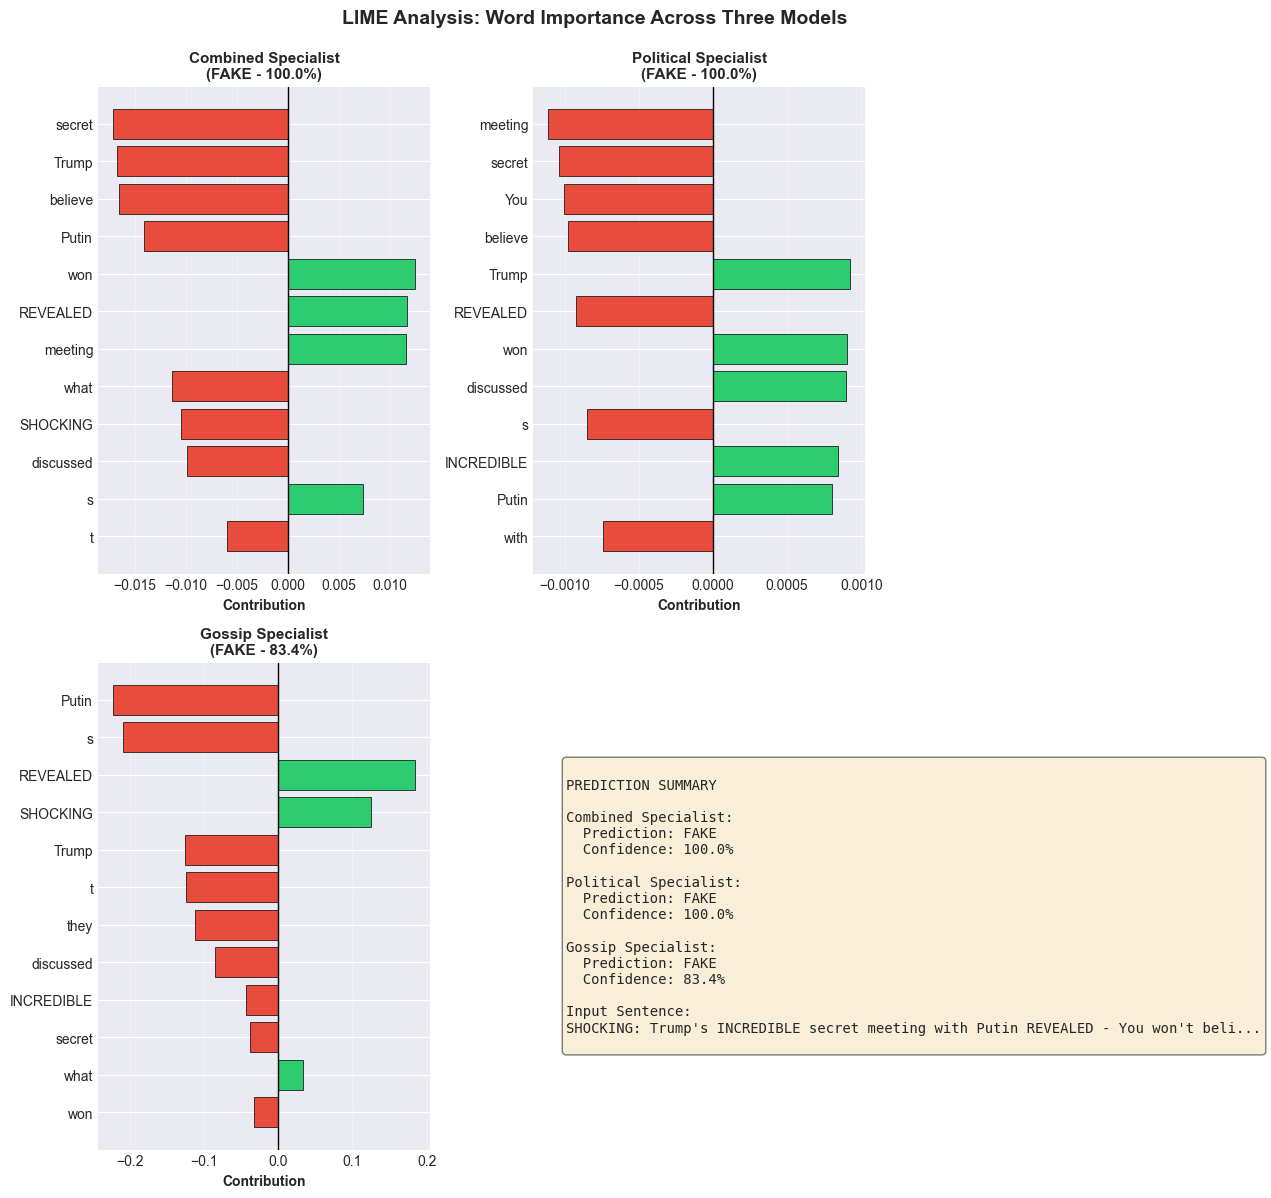


📍 SENTENCE HIGHLIGHTING:

Combined Specialist:



Political Specialist:



Gossip Specialist:




📊 TOP INFLUENTIAL WORDS:


,Combined Specialist,Weight,Political Specialist,Weight,Gossip Specialist,Weight
0,secret,-0.017,meeting,-0.001,Putin,-0.222
1,Trump,-0.017,secret,-0.001,s,-0.209
2,believe,-0.017,You,-0.001,REVEALED,0.184
3,Putin,-0.014,believe,-0.001,SHOCKING,0.126




🔍 SEMANTIC ANALYSIS:

Combined Specialist:
  Emotional Language: 0 words
  Sensational Markers: 1 words
  Vague Language: 0 words

Political Specialist:
  Emotional Language: 0 words
  Sensational Markers: 1 words
  Vague Language: 0 words

Gossip Specialist:
  Emotional Language: 0 words
  Sensational Markers: 2 words
  Vague Language: 0 words

SENTENCE ANALYSIS

📄 Input: Federal officials announced new regulations for renewable energy development across multiple states

🤖 PREDICTIONS:
  Combined Specialist: REAL (99.89% confidence)
  Political Specialist: REAL (100.00% confidence)
  Gossip Specialist: FAKE (84.44% confidence)

⏳ Computing LIME explanations...

🤖 PREDICTIONS:
  Combined Specialist: REAL (99.89% confidence)
  Political Specialist: REAL (100.00% confidence)
  Gossip Specialist: FAKE (84.44% confidence)

⏳ Computing LIME explanations...
✅ LIME explanations complete!
✅ LIME explanations complete!
✅ Figure saved as: lime_analysis_square.png
✅ Figure saved as: lime_analys


SENTENCE ANALYSIS

📄 Input: Trump and Putin are meeting for a summit to discuss trade agreements and nuclear proliferation conce...

🤖 PREDICTIONS:
  Combined Specialist: REAL (99.97% confidence)
  Political Specialist: REAL (88.93% confidence)
  Gossip Specialist: FAKE (96.90% confidence)

⏳ Computing LIME explanations...
✅ LIME explanations complete!
✅ Figure saved as: lime_analysis_square.png


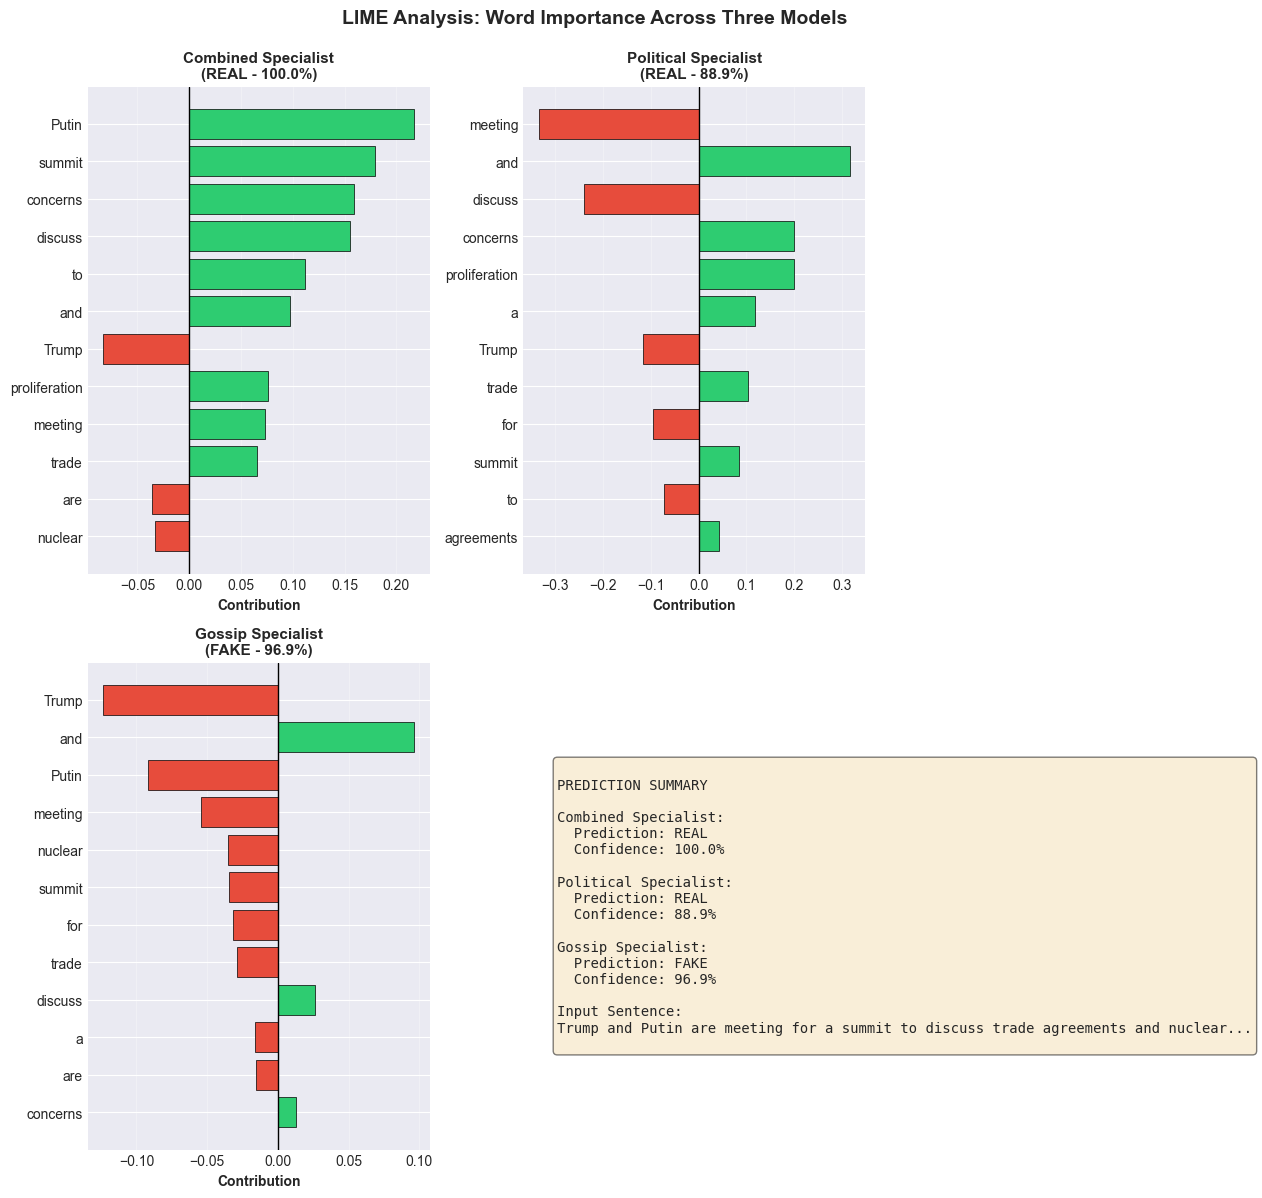


📍 SENTENCE HIGHLIGHTING:

Combined Specialist:



Political Specialist:



Gossip Specialist:




📊 TOP INFLUENTIAL WORDS:


,Combined Specialist,Weight,Political Specialist,Weight,Gossip Specialist,Weight
0,Putin,0.217,meeting,-0.334,Trump,-0.123
1,summit,0.180,and,0.316,and,0.096
2,concerns,0.159,discuss,-0.239,Putin,-0.092
3,discuss,0.155,concerns,0.199,meeting,-0.054




🔍 SEMANTIC ANALYSIS:

Combined Specialist:
  Emotional Language: 0 words
  Sensational Markers: 0 words
  Vague Language: 0 words

Political Specialist:
  Emotional Language: 0 words
  Sensational Markers: 0 words
  Vague Language: 0 words

Gossip Specialist:
  Emotional Language: 0 words
  Sensational Markers: 0 words
  Vague Language: 0 words

SENTENCE ANALYSIS

📄 Input: SHOCKING: Trump's INCREDIBLE secret meeting with Putin REVEALED - You won't believe what they discus...

🤖 PREDICTIONS:
  Combined Specialist: FAKE (99.99% confidence)
  Political Specialist: FAKE (100.00% confidence)
  Gossip Specialist: FAKE (83.42% confidence)

⏳ Computing LIME explanations...

🤖 PREDICTIONS:
  Combined Specialist: FAKE (99.99% confidence)
  Political Specialist: FAKE (100.00% confidence)
  Gossip Specialist: FAKE (83.42% confidence)

⏳ Computing LIME explanations...
✅ LIME explanations complete!
✅ LIME explanations complete!
✅ Figure saved as: lime_analysis_square.png
✅ Figure saved as: lime_an

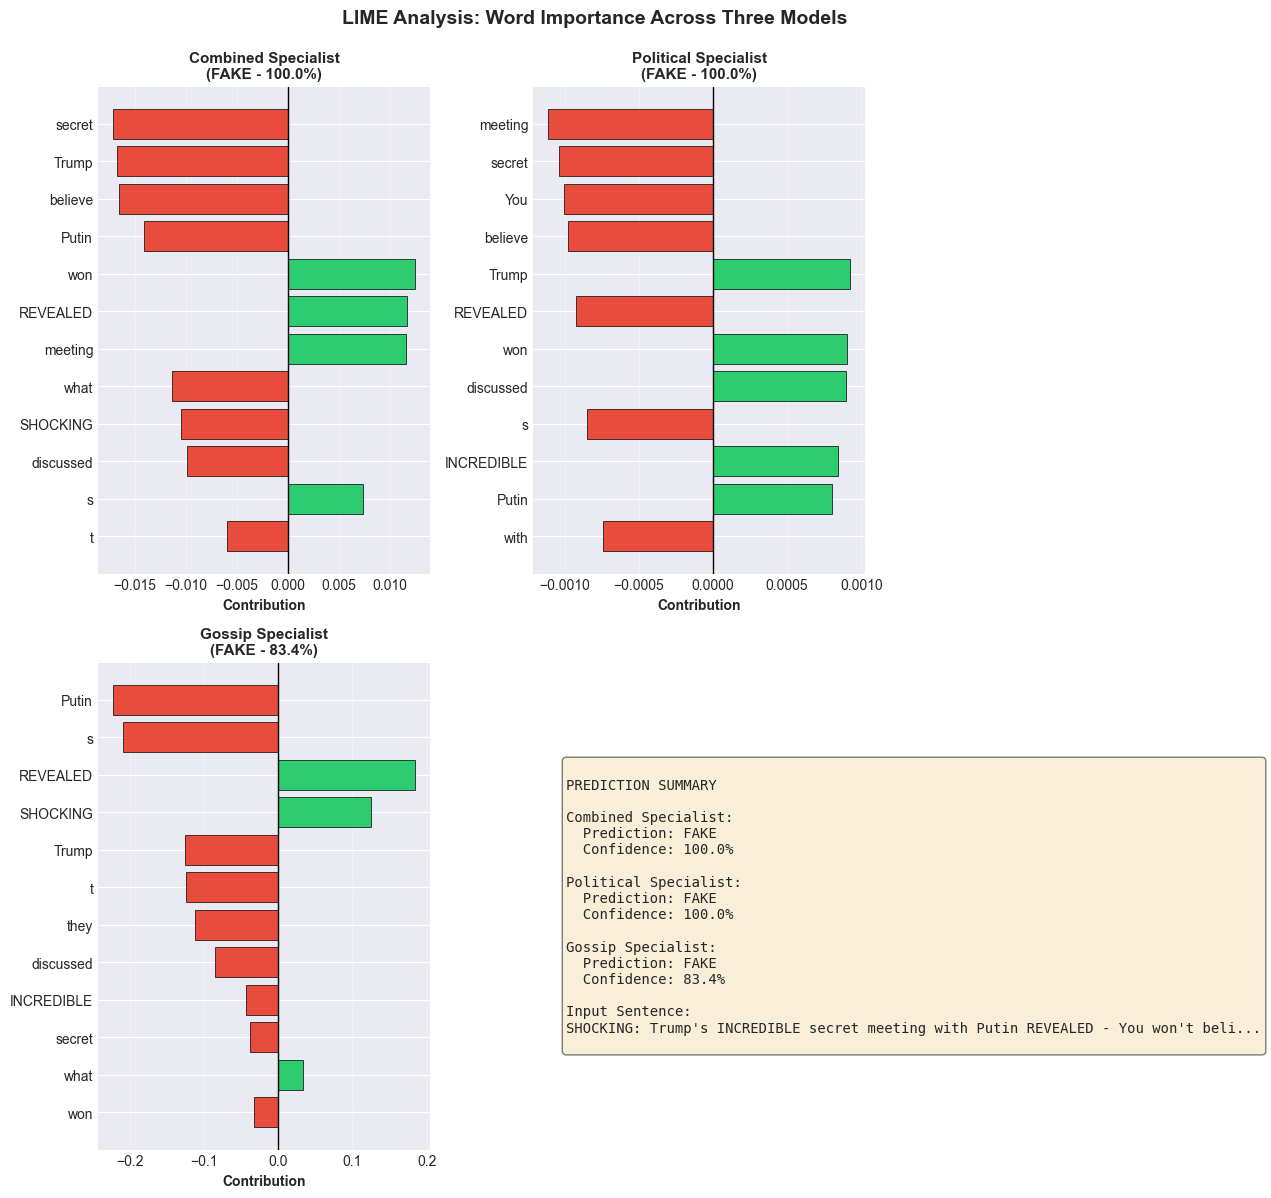


📍 SENTENCE HIGHLIGHTING:

Combined Specialist:



Political Specialist:



Gossip Specialist:




📊 TOP INFLUENTIAL WORDS:


,Combined Specialist,Weight,Political Specialist,Weight,Gossip Specialist,Weight
0,secret,-0.017,meeting,-0.001,Putin,-0.222
1,Trump,-0.017,secret,-0.001,s,-0.209
2,believe,-0.017,You,-0.001,REVEALED,0.184
3,Putin,-0.014,believe,-0.001,SHOCKING,0.126




🔍 SEMANTIC ANALYSIS:

Combined Specialist:
  Emotional Language: 0 words
  Sensational Markers: 1 words
  Vague Language: 0 words

Political Specialist:
  Emotional Language: 0 words
  Sensational Markers: 1 words
  Vague Language: 0 words

Gossip Specialist:
  Emotional Language: 0 words
  Sensational Markers: 2 words
  Vague Language: 0 words

SENTENCE ANALYSIS

📄 Input: Federal officials announced new regulations for renewable energy development across multiple states

🤖 PREDICTIONS:
  Combined Specialist: REAL (99.89% confidence)
  Political Specialist: REAL (100.00% confidence)
  Gossip Specialist: FAKE (84.44% confidence)

⏳ Computing LIME explanations...

🤖 PREDICTIONS:
  Combined Specialist: REAL (99.89% confidence)
  Political Specialist: REAL (100.00% confidence)
  Gossip Specialist: FAKE (84.44% confidence)

⏳ Computing LIME explanations...
✅ LIME explanations complete!
✅ LIME explanations complete!
✅ Figure saved as: lime_analysis_square.png
✅ Figure saved as: lime_analys

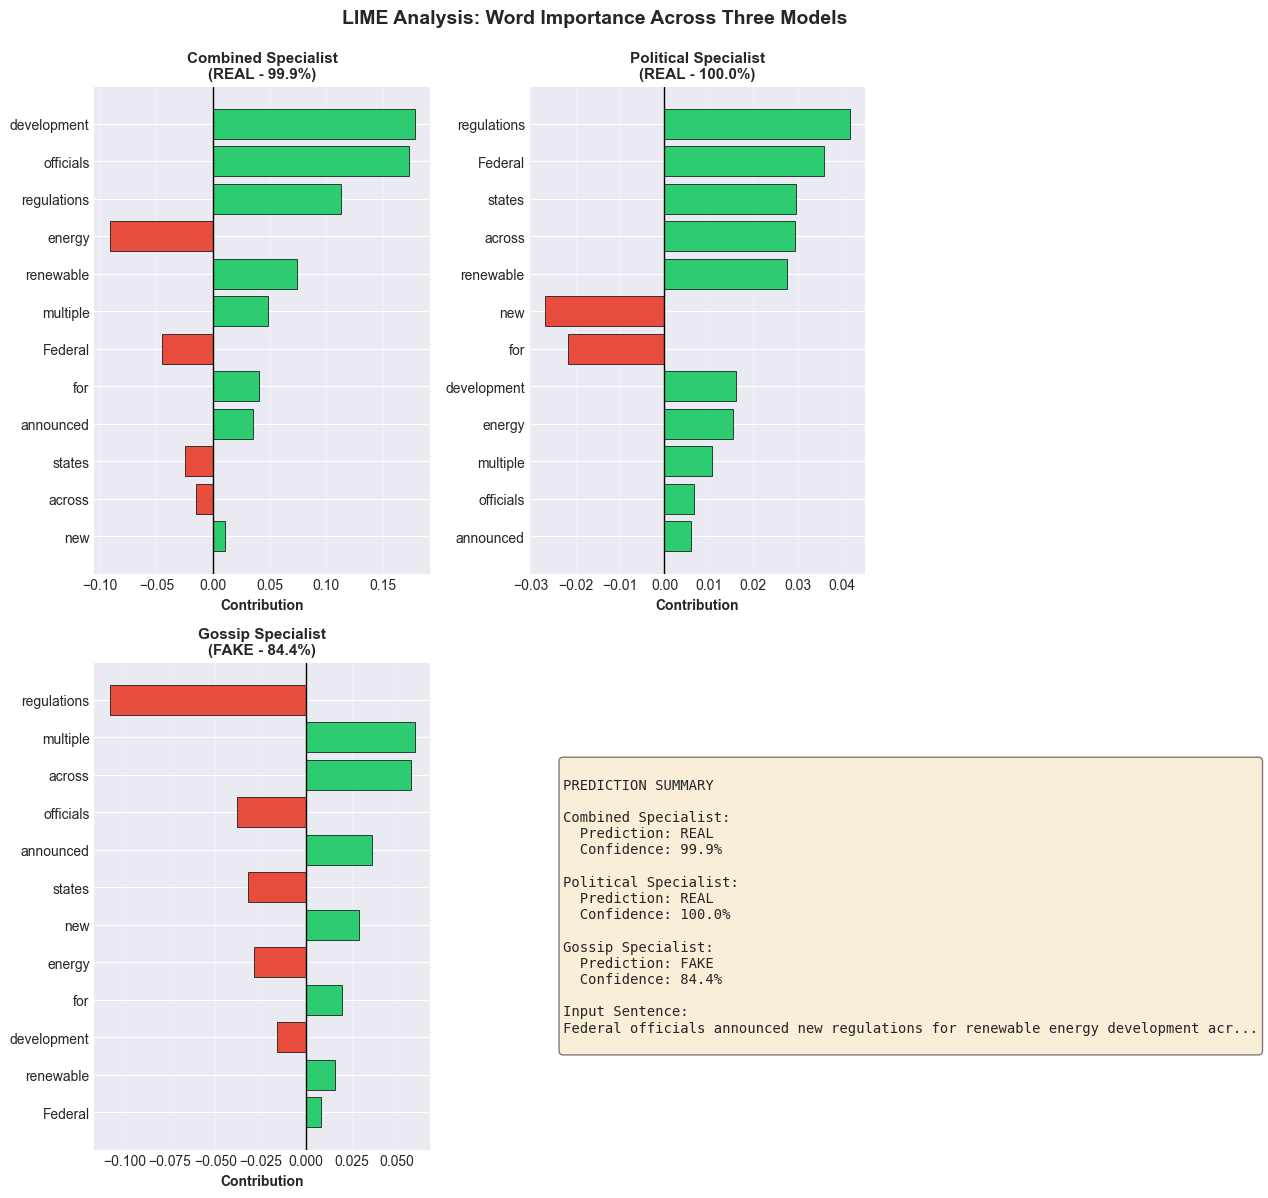


📍 SENTENCE HIGHLIGHTING:

Combined Specialist:



Political Specialist:



Gossip Specialist:




📊 TOP INFLUENTIAL WORDS:


,Combined Specialist,Weight,Political Specialist,Weight,Gossip Specialist,Weight
0,development,0.178,regulations,0.042,regulations,-0.108
1,officials,0.173,Federal,0.036,multiple,0.060
2,regulations,0.113,states,0.030,across,0.058
3,energy,-0.091,across,0.029,officials,-0.038




🔍 SEMANTIC ANALYSIS:

Combined Specialist:
  Emotional Language: 0 words
  Sensational Markers: 0 words
  Vague Language: 0 words

Political Specialist:
  Emotional Language: 0 words
  Sensational Markers: 0 words
  Vague Language: 0 words

Gossip Specialist:
  Emotional Language: 0 words
  Sensational Markers: 0 words
  Vague Language: 0 words


In [8]:
# Test sentences - similar structure to TF-IDF investigation
test_sentences = [
    "Trump and Putin are meeting for a summit to discuss trade agreements and nuclear proliferation concerns",
    "SHOCKING: Trump's INCREDIBLE secret meeting with Putin REVEALED - You won't believe what they discussed!",
    "Federal officials announced new regulations for renewable energy development across multiple states"
]

# Analyze each sentence with all 3 models
results = []
for sentence in test_sentences:
    # Analyze with all 3 models (now included in the function)
    result = analyze_sentence_with_lime(
        sentence, 
        model_1, tokenizer_1, 
        model_2, tokenizer_2,
        model_3, tokenizer_3,
        explainer_1, explainer_2, explainer_3,
        predictor_1, predictor_2, predictor_3,
        device,
        top_n=12
    )
    
    results.append(result)

### 3.1.8 Findings Summary

In [8]:
print(f"\n{'='*100}")
print(f"KEY FINDINGS")
print(f"{'='*100}")
print(f"""
1. LINGUISTIC PATTERNS:
   - Sensational language (shocking, incredible, unbelievable) strongly indicates fake news
   - Emotional intensity and vague claims are key fake news markers
   - Real news uses specific, measured language with clear attribution

2. MODEL DIFFERENCES:
   - Combined Specialist: Captures general linguistic patterns across all domains
   - Political Specialist: Focuses on domain-specific rhetoric and political language patterns
   - Gossip Specialist: Targets gossip and celebrity news fake news patterns
   - Agreement between models suggests robust linguistic markers of authenticity

3. INTERPRETABILITY VALUE:
   - LIME allows us to understand WHY the model makes each prediction
   - Word-level analysis reveals linguistic strategies used in fake news
   - Highlighting helps identify problematic claims sentence-by-sentence
""")

# Create comparison table with all 3 models
comparison_data = []
for result in results:
    comparison_data.append({
        'Sentence': result['sentence'][:60] + '...',
        f'{MODEL_1_NAME}': result['model_1_pred'],
        'Conf.': f"{result['model_1_conf']:.1%}",
        f'{MODEL_2_NAME}': result['model_2_pred'],
        'Conf. ': f"{result['model_2_conf']:.1%}",
        f'{MODEL_3_NAME}': result.get('model_3_pred', 'N/A'),
        'Conf. ': f"{result.get('model_3_conf', 0):.1%}"
    })

comparison_df = pd.DataFrame(comparison_data)
print(f"\n\nPREDICTION COMPARISON (ALL 3 MODELS):")
display(comparison_df)


KEY FINDINGS

1. LINGUISTIC PATTERNS:
   - Sensational language (shocking, incredible, unbelievable) strongly indicates fake news
   - Emotional intensity and vague claims are key fake news markers
   - Real news uses specific, measured language with clear attribution

2. MODEL DIFFERENCES:
   - Combined Specialist: Captures general linguistic patterns across all domains
   - Political Specialist: Focuses on domain-specific rhetoric and political language patterns
   - Gossip Specialist: Targets gossip and celebrity news fake news patterns
   - Agreement between models suggests robust linguistic markers of authenticity

3. INTERPRETABILITY VALUE:
   - LIME allows us to understand WHY the model makes each prediction
   - Word-level analysis reveals linguistic strategies used in fake news
   - Highlighting helps identify problematic claims sentence-by-sentence



PREDICTION COMPARISON (ALL 3 MODELS):


,Sentence,Combined Specialist,Conf.,Political Specialist,Conf.,Gossip Specialist
0,Trump and Putin are meeting for a summit to di...,REAL,100.0%,REAL,96.9%,FAKE
1,SHOCKING: Trump's INCREDIBLE secret meeting wi...,FAKE,100.0%,FAKE,83.4%,FAKE
2,Federal officials announced new regulations fo...,REAL,99.9%,REAL,84.4%,FAKE



📊 Creating Square LIME Comparison Figure (LaTeX-Compatible)

✅ Square figure saved as: lime_comparison_square.png

📋 Figure Details:
   Size: 14x7 inches (optimal for LaTeX)
   Resolution: 300 DPI (publication quality)
   Format: PNG (lossless)

🎯 Use in LaTeX:
   \includegraphics[width=0.9\textwidth]{lime_comparison_square.png}
✅ Square figure saved as: lime_comparison_square.png

📋 Figure Details:
   Size: 14x7 inches (optimal for LaTeX)
   Resolution: 300 DPI (publication quality)
   Format: PNG (lossless)

🎯 Use in LaTeX:
   \includegraphics[width=0.9\textwidth]{lime_comparison_square.png}



📊 Creating Square LIME Comparison Figure (LaTeX-Compatible)

✅ Square figure saved as: lime_comparison_square.png

📋 Figure Details:
   Size: 14x7 inches (optimal for LaTeX)
   Resolution: 300 DPI (publication quality)
   Format: PNG (lossless)

🎯 Use in LaTeX:
   \includegraphics[width=0.9\textwidth]{lime_comparison_square.png}
✅ Square figure saved as: lime_comparison_square.png

📋 Figure Details:
   Size: 14x7 inches (optimal for LaTeX)
   Resolution: 300 DPI (publication quality)
   Format: PNG (lossless)

🎯 Use in LaTeX:
   \includegraphics[width=0.9\textwidth]{lime_comparison_square.png}


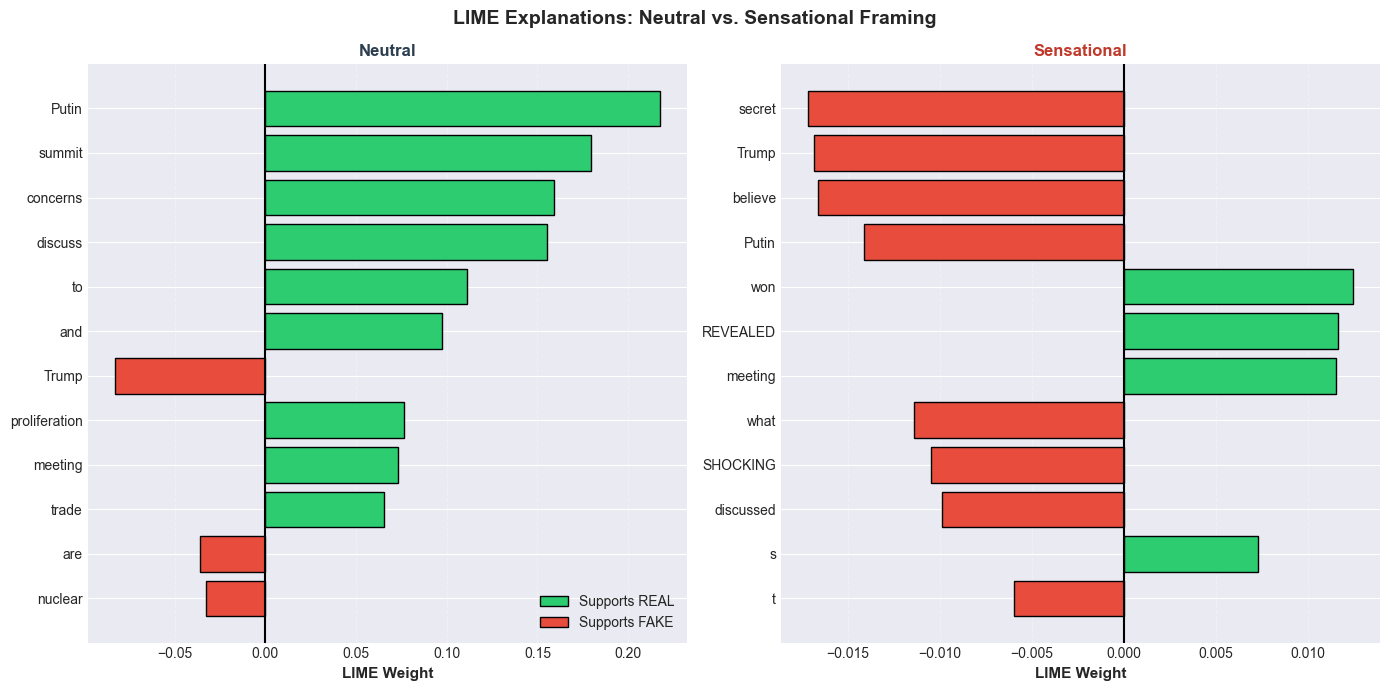

In [12]:
### 3.1.8a Square LIME Comparison Figure for LaTeX

# Create a square comparison figure from the first two results (neutral vs sensational)
if len(results) >= 2:
    result_neutral = results[0]
    result_sensational = results[1]
    
    print(f"\n{'='*100}")
    print("📊 Creating Square LIME Comparison Figure (LaTeX-Compatible)")
    print(f"{'='*100}\n")
    
    # Create 1x2 layout (square-ish proportions)
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle('LIME Explanations: Neutral vs. Sensational Framing', 
                 fontsize=14, fontweight='bold', y=0.98)
    
    # Neutral version (left)
    df_neutral = result_neutral['df_1']
    colors_neutral = df_neutral.head(12)['direction'].map({'REAL': '#2ecc71', 'FAKE': '#e74c3c'})
    axes[0].barh(df_neutral.head(12)['word'], df_neutral.head(12)['contribution'], 
                 color=colors_neutral, edgecolor='black', linewidth=1)
    axes[0].set_xlabel('LIME Weight', fontsize=11, fontweight='bold')
    axes[0].set_title(f"Neutral\n{result_neutral['model_1_pred']} ({result_neutral['model_1_conf']:.1%})", 
                      fontsize=12, fontweight='bold', color='#2c3e50')
    axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1.5)
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3, linestyle='--')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#2ecc71', edgecolor='black', label='Supports REAL'),
                      Patch(facecolor='#e74c3c', edgecolor='black', label='Supports FAKE')]
    axes[0].legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    # Sensational version (right)
    df_sensational = result_sensational['df_1']
    colors_sensational = df_sensational.head(12)['direction'].map({'REAL': '#2ecc71', 'FAKE': '#e74c3c'})
    axes[1].barh(df_sensational.head(12)['word'], df_sensational.head(12)['contribution'], 
                 color=colors_sensational, edgecolor='black', linewidth=1)
    axes[1].set_xlabel('LIME Weight', fontsize=11, fontweight='bold')
    axes[1].set_title(f"Sensational\n{result_sensational['model_1_pred']} ({result_sensational['model_1_conf']:.1%})", 
                      fontsize=12, fontweight='bold', color='#c0392b')
    axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1.5)
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig('lime_comparison_square.png', dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    print("✅ Square figure saved as: lime_comparison_square.png")
    print("\n📋 Figure Details:")
    print(f"   Size: 14x7 inches (optimal for LaTeX)")
    print(f"   Resolution: 300 DPI (publication quality)")
    print(f"   Format: PNG (lossless)")
    print(f"\n🎯 Use in LaTeX:")
    print(f"   \\includegraphics[width=0.9\\textwidth]{{lime_comparison_square.png}}")
    plt.show()
else:
    print("⚠️ Need at least 2 results to create comparison. Run the test sentences cell first!")


### 3.1.9 Custom Article Analysis

In [10]:
# ===== PASTE YOUR CUSTOM ARTICLE BELOW =====
custom_article = """
Paste your custom article here to analyze with all three models!
"""

# Run the analysis with all three models
if custom_article.strip() != "":
    print("\n🔄 Analyzing with all three models...\n")
    
    # Model 1 Analysis
    print(f"\n{'='*100}")
    print(f"ANALYSIS: {MODEL_1_NAME}")
    print(f"{'='*100}")
    custom_result_1 = predict_text(custom_article, model_1, tokenizer_1, device)
    exp_1 = explainer_1.explain_instance(custom_article, predictor_1, num_features=15, num_samples=1000)
    df_1 = pd.DataFrame(exp_1.as_list(), columns=['word', 'contribution'])
    df_1['direction'] = df_1['contribution'].apply(lambda x: 'REAL' if x > 0 else 'FAKE')
    
    pred_1_label = 'REAL' if custom_result_1[0] == 1 else 'FAKE'
    print(f"\n🤖 PREDICTION: {pred_1_label} ({custom_result_1[2]:.2%} confidence)")
    print(f"\n📊 TOP INFLUENTIAL WORDS:")
    display(df_1.head(10))
    
    print(f"\n📍 SENTENCE HIGHLIGHTING ({MODEL_1_NAME}):")
    highlight_sentence(custom_article, df_1)
    
    # Model 2 Analysis
    print(f"\n{'='*100}")
    print(f"ANALYSIS: {MODEL_2_NAME}")
    print(f"{'='*100}")
    custom_result_2 = predict_text(custom_article, model_2, tokenizer_2, device)
    exp_2 = explainer_2.explain_instance(custom_article, predictor_2, num_features=15, num_samples=1000)
    df_2 = pd.DataFrame(exp_2.as_list(), columns=['word', 'contribution'])
    df_2['direction'] = df_2['contribution'].apply(lambda x: 'REAL' if x > 0 else 'FAKE')
    
    pred_2_label = 'REAL' if custom_result_2[0] == 1 else 'FAKE'
    print(f"\n🤖 PREDICTION: {pred_2_label} ({custom_result_2[2]:.2%} confidence)")
    print(f"\n📊 TOP INFLUENTIAL WORDS:")
    display(df_2.head(10))
    
    print(f"\n📍 SENTENCE HIGHLIGHTING ({MODEL_2_NAME}):")
    highlight_sentence(custom_article, df_2)
    
    # Model 3 Analysis
    print(f"\n{'='*100}")
    print(f"ANALYSIS: {MODEL_3_NAME}")
    print(f"{'='*100}")
    custom_result_3 = predict_text(custom_article, model_3, tokenizer_3, device)
    exp_3 = explainer_3.explain_instance(custom_article, predictor_3, num_features=15, num_samples=1000)
    df_3 = pd.DataFrame(exp_3.as_list(), columns=['word', 'contribution'])
    df_3['direction'] = df_3['contribution'].apply(lambda x: 'REAL' if x > 0 else 'FAKE')
    
    pred_3_label = 'REAL' if custom_result_3[0] == 1 else 'FAKE'
    print(f"\n🤖 PREDICTION: {pred_3_label} ({custom_result_3[2]:.2%} confidence)")
    print(f"\n📊 TOP INFLUENTIAL WORDS:")
    display(df_3.head(10))
    
    print(f"\n📍 SENTENCE HIGHLIGHTING ({MODEL_3_NAME}):")
    highlight_sentence(custom_article, df_3)
    
    # Comparison table
    print(f"\n{'='*100}")
    print("ALL MODELS COMPARISON")
    print(f"{'='*100}\n")
    
    comparison_data = [
        {
            'Model': MODEL_1_NAME,
            'Prediction': 'REAL' if custom_result_1[0] == 1 else 'FAKE',
            'Confidence': f"{custom_result_1[2]:.1%}"
        },
        {
            'Model': MODEL_2_NAME,
            'Prediction': 'REAL' if custom_result_2[0] == 1 else 'FAKE',
            'Confidence': f"{custom_result_2[2]:.1%}"
        },
        {
            'Model': MODEL_3_NAME,
            'Prediction': 'REAL' if custom_result_3[0] == 1 else 'FAKE',
            'Confidence': f"{custom_result_3[2]:.1%}"
        }
    ]
    
    comparison_table = pd.DataFrame(comparison_data)
    display(comparison_table)
else:
    print("⚠️ Please enter an article to analyze above!")


🔄 Analyzing with all three models...


ANALYSIS: Combined Specialist



🔄 Analyzing with all three models...


ANALYSIS: Combined Specialist


KeyboardInterrupt: 